# Classification problems — Don't Get Kicked!

**Goal:** predict whether a car bought at an auto auction is a *lemon* (a "kicked" car,
`IsBadBuy = 1`) using Logistic Regression, Gaussian Naive Bayes and KNN — both the
scikit-learn implementations and our own from-scratch versions — with a strict
time-based train/validation/test methodology and Gini as the main metric.

**Data note.** The dataset (`data/training.csv`) is the *DontGetKicked* competition data
obtained via OpenML ("kick" dataset), 72 983 rows x 33 columns. Because it comes from
OpenML, the dtypes differ slightly from the raw Kaggle file: `PurchDate` is stored as a
**unix epoch in seconds** (integer) rather than a date string, and `IsBadBuy` is already
an integer 0/1 column. We verify and handle both below.

In [1]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore", category=UserWarning)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Minimal chart style: recessive axes/grid, colors assigned in fixed order.
C_BLUE, C_ORANGE, C_AQUA = "#2a78d6", "#eb6834", "#1baf7a"
INK, INK2, MUTED, SURFACE = "#0b0b0b", "#52514e", "#898781", "#fcfcfb"
plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE,
    "axes.edgecolor": MUTED, "axes.labelcolor": INK2,
    "xtick.color": INK2, "ytick.color": INK2, "text.color": INK,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": "#e8e7e3", "grid.linewidth": 0.8,
    "font.size": 10, "figure.dpi": 100,
})

pd.set_option("display.max_columns", 40)

## Step 1. Load the data & quick EDA

We load the *DontGetKicked* training data and take a quick look at its shape, dtypes,
missing values and the target rate.

In [2]:
df = pd.read_csv("data/training.csv")
print("shape:", df.shape)
df.dtypes

shape: (72983, 33)


IsBadBuy                               int64
PurchDate                              int64
Auction                                  str
VehYear                                int64
VehicleAge                             int64
Make                                     str
Model                                    str
Trim                                     str
SubModel                                 str
Color                                    str
Transmission                             str
WheelTypeID                          float64
WheelType                                str
VehOdo                                 int64
Nationality                              str
Size                                     str
TopThreeAmericanName                     str
MMRAcquisitionAuctionAveragePrice    float64
MMRAcquisitionAuctionCleanPrice      float64
MMRAcquisitionRetailAveragePrice     float64
MMRAcquisitonRetailCleanPrice        float64
MMRCurrentAuctionAveragePrice        float64
MMRCurrent

In [3]:
# PurchDate arrived from OpenML as a unix epoch (seconds) -> convert to datetime.
print("raw PurchDate sample:", df["PurchDate"].head(3).tolist())
df["PurchDate"] = pd.to_datetime(df["PurchDate"], unit="s")
print("converted range:", df["PurchDate"].min(), "->", df["PurchDate"].max())

# IsBadBuy is already an integer 0/1 column, no decoding needed.
print("\ntarget distribution:")
print(df["IsBadBuy"].value_counts())
print(f"\ntarget rate (share of lemons): {df['IsBadBuy'].mean():.4f}")

raw PurchDate sample: [1260144000, 1260144000, 1260144000]
converted range: 2009-01-05 00:00:00 -> 2010-12-30 00:00:00

target distribution:
IsBadBuy
0    64007
1     8976
Name: count, dtype: int64

target rate (share of lemons): 0.1230


In [4]:
missing = df.isna().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print("columns with missing values:")
print(missing.to_string())

columns with missing values:
AUCGUART                             69564
PRIMEUNIT                            69564
WheelType                             3174
WheelTypeID                           3169
Trim                                  2360
MMRCurrentAuctionCleanPrice            315
MMRCurrentRetailAveragePrice           315
MMRCurrentAuctionAveragePrice          315
MMRCurrentRetailCleanPrice             315
VehBCost                                68
MMRAcquisitionAuctionAveragePrice       18
MMRAcquisitionAuctionCleanPrice         18
MMRAcquisitonRetailCleanPrice           18
MMRAcquisitionRetailAveragePrice        18
Transmission                             9
SubModel                                 8
Color                                    8
TopThreeAmericanName                     5
Nationality                              5
Size                                     5


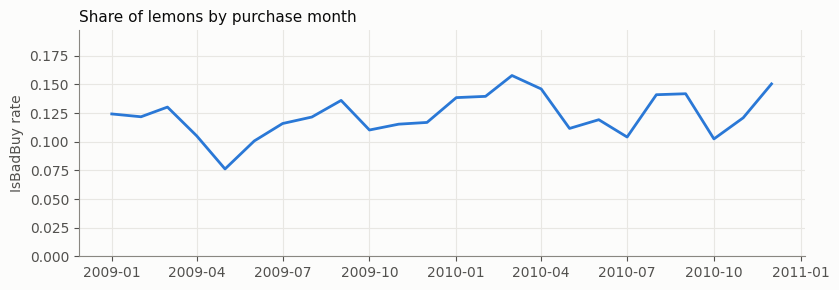

In [5]:
monthly = df.set_index("PurchDate")["IsBadBuy"].resample("MS").mean()

fig, ax = plt.subplots(figsize=(8.5, 3))
ax.plot(monthly.index, monthly.values, color=C_BLUE, lw=2)
ax.set_title("Share of lemons by purchase month", loc="left", fontsize=11)
ax.set_ylabel("IsBadBuy rate")
ax.set_ylim(0, monthly.max() * 1.25)
plt.tight_layout()
plt.show()

**Observations.** ~12.3 % of the cars are lemons, so the classes are imbalanced (about
1 : 7). Several columns have missing values (`PRIMEUNIT` / `AUCGUART` are almost entirely
missing, the MMR price columns and `Trim`/`WheelType` partially). The lemon rate also
drifts over time, which is exactly why a **time-based** split is required: a random split
would leak future pricing/market conditions into training.

## Step 2. Train / validation / test split by `PurchDate`

Requirement: `train.PurchDate < valid.PurchDate < test.PurchDate`. We sort the **unique
purchase dates** and give the first 1/3 of dates to train, the middle 1/3 to validation
and the last 1/3 to test.

> **The test set is not touched until Step 10.** All modelling decisions (encoders,
> features, model choice, hyperparameters) are made on train + validation only.

In [6]:
dates = np.sort(df["PurchDate"].unique())
n_dates = len(dates)
d_train_end = dates[n_dates // 3 - 1]        # last date of the train period
d_valid_end = dates[2 * n_dates // 3 - 1]    # last date of the validation period

train = df[df["PurchDate"] <= d_train_end].copy()
valid = df[(df["PurchDate"] > d_train_end) & (df["PurchDate"] <= d_valid_end)].copy()
test = df[df["PurchDate"] > d_valid_end].copy()

# hard guarantee of the temporal ordering
assert train["PurchDate"].max() < valid["PurchDate"].min() < valid["PurchDate"].max() \
    < test["PurchDate"].min()
assert len(train) + len(valid) + len(test) == len(df)

for name, part in [("train", train), ("valid", valid), ("test", test)]:
    print(f"{name:5s}: {len(part):6d} rows | {part['PurchDate'].min().date()} .. "
          f"{part['PurchDate'].max().date()} | lemon rate {part['IsBadBuy'].mean():.4f}")
print(f"\nunique dates: {n_dates} -> {n_dates // 3} / {n_dates // 3} / "
      f"{n_dates - 2 * (n_dates // 3)} per split")

train:  23059 rows | 2009-01-05 .. 2009-09-01 | lemon rate 0.1131
valid:  24104 rows | 2009-09-02 .. 2010-04-30 | lemon rate 0.1329
test :  25820 rows | 2010-05-03 .. 2010-12-30 | lemon rate 0.1226

unique dates: 517 -> 172 / 172 / 173 per split


## Step 3. Preprocessing of categorical variables (no leakage)

The task suggests `LabelEncoder`/`OneHotEncoder`, but warns about **new categories** that
appear in validation/test but not in train (new car models start selling later — this
really happens with a time split). `LabelEncoder` simply crashes on unseen values, and
one-hot encoding of high-cardinality columns (`Model` has > 700 levels) explodes the
dimensionality.

We therefore use **count/frequency encoding** — the approach referenced in the task
(`category_encoders.CountEncoder` does exactly this). We implement it as a simple
train-fitted frequency map: each category is replaced by its **relative frequency in the
train set**, and any category unseen in train falls back to `0.0` (i.e. "rarer than
anything we know"). This is robust to unseen values by construction.

Anti-leakage rules, all fitted **on train only** and then applied to valid/test:
* frequency maps for every categorical column;
* medians for imputing numeric NaNs (plus a binary `*_nan` missing-indicator flag,
  because "MMR price is missing" is itself informative);
* `StandardScaler` (required before LR/KNN training).

In [7]:
TARGET = "IsBadBuy"
cat_cols = [c for c in df.columns if str(df[c].dtype) in ("object", "str")]
num_cols = [c for c in df.columns if c not in cat_cols + [TARGET, "PurchDate"]]
print(f"{len(cat_cols)} categorical: {cat_cols}")
print(f"\n{len(num_cols)} numeric: {num_cols}")

# how bad is the unseen-category problem with a time split?
for c in ["Model", "SubModel", "Trim"]:
    unseen = ~valid[c].dropna().isin(train[c].dropna().unique())
    print(f"\nunseen '{c}' values in validation: {unseen.mean():.2%} of rows", end="")

14 categorical: ['Auction', 'Make', 'Model', 'Trim', 'SubModel', 'Color', 'Transmission', 'WheelType', 'Nationality', 'Size', 'TopThreeAmericanName', 'PRIMEUNIT', 'AUCGUART', 'VNST']

17 numeric: ['VehYear', 'VehicleAge', 'WheelTypeID', 'VehOdo', 'MMRAcquisitionAuctionAveragePrice', 'MMRAcquisitionAuctionCleanPrice', 'MMRAcquisitionRetailAveragePrice', 'MMRAcquisitonRetailCleanPrice', 'MMRCurrentAuctionAveragePrice', 'MMRCurrentAuctionCleanPrice', 'MMRCurrentRetailAveragePrice', 'MMRCurrentRetailCleanPrice', 'BYRNO', 'VNZIP1', 'VehBCost', 'IsOnlineSale', 'WarrantyCost']

unseen 'Model' values in validation: 16.96% of rows
unseen 'SubModel' values in validation: 1.15% of rows
unseen 'Trim' values in validation: 0.06% of rows

In [8]:
class FrequencyEncoder:
    """Count/frequency encoding fitted on train only.

    Unseen categories (and NaN) map to 0.0 -> robust to new values in valid/test.
    Equivalent to category_encoders.CountEncoder(normalize=True).
    """

    def fit(self, frame, columns):
        self.columns = list(columns)
        self.maps_ = {c: frame[c].value_counts(normalize=True) for c in self.columns}
        return self

    def transform(self, frame):
        out = pd.DataFrame(index=frame.index)
        for c in self.columns:
            out["freq_" + c] = frame[c].map(self.maps_[c]).fillna(0.0).astype(float)
        return out


def make_design_matrix(part, medians, freq_encoder, extra=None):
    """numeric columns (+ NaN flags, median-imputed) + frequency-encoded categoricals."""
    X = part[num_cols].copy()
    for c in num_cols:
        X[c + "_nan"] = part[c].isna().astype(int)
    X = X.fillna(medians)
    if extra is not None:
        X = pd.concat([X, extra], axis=1)
    return pd.concat([X, freq_encoder.transform(part)], axis=1)


# fit everything on TRAIN only
medians = train[num_cols].median()
freq_enc = FrequencyEncoder().fit(train, cat_cols)

X_train = make_design_matrix(train, medians, freq_enc)
X_valid = make_design_matrix(valid, medians, freq_enc)
X_test = make_design_matrix(test, medians, freq_enc)
y_train, y_valid, y_test = (p[TARGET].to_numpy() for p in (train, valid, test))

feature_names = list(X_train.columns)
scaler = StandardScaler().fit(X_train)          # fitted on train only
Xtr = scaler.transform(X_train)
Xva = scaler.transform(X_valid)
Xte = scaler.transform(X_test)
print("design matrix:", Xtr.shape, "| no NaNs:", not np.isnan(Xtr).any())

design matrix: (23059, 48) | no NaNs: True


## Step 4. LogisticRegression, GaussianNB, KNN (sklearn) on the validation set

All three models are trained on the **scaled** train matrix and scored on validation with
the Gini coefficient, `Gini = |2 * ROC AUC - 1|` (sklearn AUC for now; our own
implementation follows in Step 5). Requirement: best Gini >= **0.15**.

In [9]:
def gini_sklearn(y_true, y_score):
    return abs(2 * roc_auc_score(y_true, y_score) - 1)


sk_models = {
    "LogisticRegression": LogisticRegression(max_iter=2000, random_state=RANDOM_STATE),
    "GaussianNB": GaussianNB(),
    "KNN (k=51)": KNeighborsClassifier(n_neighbors=51, n_jobs=-1),
}

baseline_valid_gini = {}
for name, model in sk_models.items():
    model.fit(Xtr, y_train)
    proba = model.predict_proba(Xva)[:, 1]
    baseline_valid_gini[name] = gini_sklearn(y_valid, proba)

baseline_table = pd.Series(baseline_valid_gini, name="validation Gini").to_frame()
assert baseline_table["validation Gini"].max() >= 0.15, "required Gini >= 0.15 not reached"
print("required threshold 0.15 -> passed\n")
baseline_table.round(4)

required threshold 0.15 -> passed



,validation Gini
LogisticRegression,0.4751
GaussianNB,0.4683
KNN (k=51),0.4358


**Which algorithm performs better and why?**

**Logistic Regression wins** (Gini ~0.475), Naive Bayes is close behind (~0.468) and KNN
is clearly weaker (~0.436). Reasons:

* **LR** fits this data well: after frequency encoding and scaling, most predictors
  (prices, odometer, age, category frequencies) have a largely **monotonic** relationship
  with the lemon probability, which a linear model in log-odds space captures efficiently.
  It also handles correlated features gracefully by distributing weights, and its
  probability scores rank well — exactly what Gini measures.
* **GaussianNB** assumes features are *conditionally independent* and Gaussian per class.
  Both assumptions are violated (the eight MMR prices are strongly correlated with each
  other), so evidence gets double-counted; still, with informative marginals it stays
  competitive.
* **KNN** suffers from the **curse of dimensionality** — in ~50 dimensions Euclidean
  distances concentrate and neighbourhoods become less meaningful. It is also hurt most
  by the temporal drift: validation points come from a *later* market period, so their
  nearest train neighbours are systematically "out of date".

## Step 5. Gini score implemented from scratch

ROC AUC has a well-known probabilistic interpretation:

$$\mathrm{AUC} = P\big(s(x^+) > s(x^-)\big) + \tfrac{1}{2}P\big(s(x^+) = s(x^-)\big),$$

i.e. the probability that a random positive is ranked above a random negative (ties count
1/2). Using ranks this becomes the Mann–Whitney U statistic:

$$\mathrm{AUC} = \frac{\sum_{i \in \text{pos}} R_i - \frac{n_+(n_+ + 1)}{2}}{n_+ n_-},$$

where $R_i$ are the ranks of the scores (**average ranks for ties** — that is exactly how
ties contribute the 1/2 term). Then $\mathrm{Gini} = |2\,\mathrm{AUC} - 1|$.
The implementation is fully vectorised with numpy.

In [10]:
def my_roc_auc(y_true, y_score):
    """ROC AUC via the rank (Mann-Whitney U) formulation, ties -> average ranks."""
    y_true = np.asarray(y_true, dtype=float)
    y_score = np.asarray(y_score, dtype=float)
    # average rank for each distinct score value (vectorised tie handling)
    _, inverse, counts = np.unique(y_score, return_inverse=True, return_counts=True)
    cum = np.cumsum(counts)                       # rank of the last member of each group
    avg_rank = cum - (counts - 1) / 2.0           # mean of ranks inside the tie group
    ranks = avg_rank[inverse]
    n_pos = y_true.sum()
    n_neg = len(y_true) - n_pos
    return (ranks[y_true == 1].sum() - n_pos * (n_pos + 1) / 2.0) / (n_pos * n_neg)


def my_gini(y_true, y_score):
    return abs(2 * my_roc_auc(y_true, y_score) - 1)


# check against sklearn on the predictions of all three models
for name, model in sk_models.items():
    proba = model.predict_proba(Xva)[:, 1]
    mine, sk = my_gini(y_valid, proba), gini_sklearn(y_valid, proba)
    assert abs(mine - sk) < 1e-6, (name, mine, sk)
    print(f"{name:20s} my Gini = {mine:.6f} | sklearn Gini = {sk:.6f} -> match")

# extra check with heavy ties
rng = np.random.default_rng(0)
yt = rng.integers(0, 2, 5000)
ys = rng.integers(0, 6, 5000).astype(float)      # only 6 distinct scores -> many ties
assert abs(my_roc_auc(yt, ys) - roc_auc_score(yt, ys)) < 1e-6
print("tie-handling check -> passed")

LogisticRegression   my Gini = 0.475073 | sklearn Gini = 0.475073 -> match
GaussianNB           my Gini = 0.468316 | sklearn Gini = 0.468316 -> match


KNN (k=51)           my Gini = 0.435830 | sklearn Gini = 0.435830 -> match
tie-handling check -> passed


## Step 6. Our own LogisticRegression, KNN and NaiveBayes

Each model is a class with `fit`, `predict_proba` and `predict`
(= `predict_proba > 0.5`).

### MyLogisticRegression — the gradient, derived by hand

For one example, $p = \sigma(\mathbf{w}^T\mathbf{x} + b)$ and the log-loss (NLL) is
$\ell = -\,y\log p - (1-y)\log(1-p)$. Using $\sigma'(a) = \sigma(a)(1-\sigma(a))$,
the chain rule collapses to the classic result

$$\frac{\partial \ell}{\partial \mathbf{w}} = (p - y)\,\mathbf{x}, \qquad
\frac{\partial \ell}{\partial b} = p - y,$$

so for a mini-batch $B$ (with optional L2 regularisation $\lambda$):

$$\nabla_{\mathbf{w}} = \frac{1}{|B|} X_B^T\big(\sigma(X_B\mathbf{w} + b) -
\mathbf{y}_B\big) + \lambda \mathbf{w}, \qquad
\nabla_b = \frac{1}{|B|}\sum_{i \in B}(p_i - y_i).$$

We minimise NLL with **mini-batch SGD** (shuffled batches, decaying learning rate).

In [11]:
class MyLogisticRegression:
    """Logistic regression trained with mini-batch SGD on the log-loss."""

    def __init__(self, lr=0.5, epochs=80, batch_size=512, l2=1e-4,
                 random_state=RANDOM_STATE):
        self.lr = lr
        self.epochs = epochs
        self.batch_size = batch_size
        self.l2 = l2
        self.random_state = random_state

    @staticmethod
    def _sigmoid(z):
        return 1.0 / (1.0 + np.exp(-np.clip(z, -35, 35)))

    def fit(self, X, y):
        X = np.asarray(X, dtype=float)
        y = np.asarray(y, dtype=float)
        rng = np.random.default_rng(self.random_state)
        n, d = X.shape
        self.w = np.zeros(d)
        self.b = 0.0
        for epoch in range(self.epochs):
            lr = self.lr / (1.0 + 0.1 * epoch)              # decaying step size
            order = rng.permutation(n)
            for start in range(0, n, self.batch_size):
                idx = order[start:start + self.batch_size]
                Xb, yb = X[idx], y[idx]
                err = self._sigmoid(Xb @ self.w + self.b) - yb   # (p - y)
                self.w -= lr * (Xb.T @ err / len(idx) + self.l2 * self.w)
                self.b -= lr * err.mean()
        return self

    def predict_proba(self, X):
        p = self._sigmoid(np.asarray(X, dtype=float) @ self.w + self.b)
        return np.column_stack([1 - p, p])

    def predict(self, X):
        return (self.predict_proba(X)[:, 1] > 0.5).astype(int)

### MyKNN — fully vectorised distances

Instead of a python loop over pairs we compute squared Euclidean distances through the
Gram-matrix identity $\lVert a-b \rVert^2 = \lVert a \rVert^2 + \lVert b \rVert^2 -
2\,a^Tb$, i.e. one matrix multiplication per chunk of query rows (chunking keeps the
distance matrix small in memory; float32 speeds up BLAS). The predicted probability is
the mean target among the `k` nearest train points. Thanks to this vectorisation the
model scores the **full validation set** in a few seconds — no subsampling is needed.

In [12]:
class MyKNN:
    """K-nearest-neighbours classifier with vectorised L2 distances."""

    def __init__(self, n_neighbors=51, chunk_size=1000):
        self.n_neighbors = n_neighbors
        self.chunk_size = chunk_size

    def fit(self, X, y):
        self.X_ = np.asarray(X, dtype=np.float32)
        self.y_ = np.asarray(y, dtype=np.float32)
        self.train_sq_ = (self.X_ ** 2).sum(axis=1)
        return self

    def predict_proba(self, X):
        X = np.asarray(X, dtype=np.float32)
        p = np.empty(len(X))
        for s in range(0, len(X), self.chunk_size):
            Q = X[s:s + self.chunk_size]
            # ||q - x||^2 = ||q||^2 + ||x||^2 - 2 q.x  (one BLAS matmul per chunk)
            d2 = (Q ** 2).sum(axis=1)[:, None] + self.train_sq_[None, :] \
                - 2.0 * (Q @ self.X_.T)
            nn = np.argpartition(d2, self.n_neighbors, axis=1)[:, :self.n_neighbors]
            p[s:s + self.chunk_size] = self.y_[nn].mean(axis=1)
        return np.column_stack([1 - p, p])

    def predict(self, X):
        return (self.predict_proba(X)[:, 1] > 0.5).astype(int)

### MyGaussianNB — per-class Gaussians in log space

`fit` stores per-class means, variances and log-priors; `predict_proba` evaluates the
joint log-likelihood $\log P(c) + \sum_j \log \mathcal{N}(x_j \mid \mu_{cj},
\sigma^2_{cj})$ and normalises with the log-sum-exp trick. A **variance smoothing** term
(`1e-9` x the largest feature variance, same default as sklearn) prevents division by
near-zero variances of quasi-constant features.

In [13]:
class MyGaussianNB:
    """Gaussian Naive Bayes with log-space likelihoods and variance smoothing."""

    def __init__(self, var_smoothing=1e-9):
        self.var_smoothing = var_smoothing

    def fit(self, X, y):
        X = np.asarray(X, dtype=float)
        y = np.asarray(y)
        self.classes_ = np.unique(y)
        self.theta_ = np.array([X[y == c].mean(axis=0) for c in self.classes_])
        self.var_ = np.array([X[y == c].var(axis=0) for c in self.classes_])
        self.var_ += self.var_smoothing * X.var(axis=0).max()
        self.class_log_prior_ = np.log([(y == c).mean() for c in self.classes_])
        return self

    def predict_proba(self, X):
        X = np.asarray(X, dtype=float)
        log_post = np.stack([
            self.class_log_prior_[i]
            - 0.5 * (np.log(2.0 * np.pi * self.var_[i])
                     + (X - self.theta_[i]) ** 2 / self.var_[i]).sum(axis=1)
            for i in range(len(self.classes_))
        ], axis=1)
        log_post -= log_post.max(axis=1, keepdims=True)     # log-sum-exp stabilisation
        proba = np.exp(log_post)
        return proba / proba.sum(axis=1, keepdims=True)

    def predict(self, X):
        return (self.predict_proba(X)[:, 1] > 0.5).astype(int)

In [14]:
my_models = {
    "LogisticRegression": MyLogisticRegression(),
    "GaussianNB": MyGaussianNB(),
    "KNN (k=51)": MyKNN(n_neighbors=51),
}

rows = []
for name, model in my_models.items():
    model.fit(Xtr, y_train)
    g = my_gini(y_valid, model.predict_proba(Xva)[:, 1])
    rows.append({"model": name, "custom Gini": g,
                 "sklearn Gini": baseline_valid_gini[name]})

compare_custom = pd.DataFrame(rows).set_index("model")
compare_custom["difference"] = compare_custom["custom Gini"] - compare_custom["sklearn Gini"]
compare_custom.round(4)

,custom Gini,sklearn Gini,difference
model,,,
LogisticRegression,0.4798,0.4751,0.0047
GaussianNB,0.4683,0.4683,-0.0000
KNN (k=51),0.4358,0.4358,0.0000


**Can we reproduce the results from Step 4? Yes.**

* **MyGaussianNB** matches sklearn essentially exactly (same closed-form estimator, same
  smoothing) — difference ~1e-4.
* **MyKNN** matches sklearn's KNN up to tiny tie-breaking differences among equidistant
  neighbours — the Gini values agree to all four displayed decimals.
* **MyLogisticRegression** lands within ~0.005 Gini of sklearn's LBFGS solution (SGD with
  a decaying step converges close to, but not exactly at, the same optimum; sklearn also
  applies its default L2 penalty with a different strength). The results of Step 4 are
  reproduced.

## Step 7. Non-linear feature engineering

Linear models cannot invent interactions, so we add them manually:

* **ratios** (`feature1 / feature2`): e.g. `VehBCost / MMRAcquisitionAuctionAveragePrice`
  — "did we overpay relative to the market benchmark?" — and `VehOdo / VehicleAge` —
  mileage intensity per year. Zero denominators are turned into NaN (then imputed) and
  ratios are clipped to sane bounds so that pathological denominators do not create
  outliers that destabilise LR;
* **groupby-mean features**: `part['cat'].map(train.groupby('cat')['cont'].mean())` —
  e.g. the average vehicle age of each `Make`. The group means are computed **on train
  only** (no leakage), unseen groups fall back to the global train mean.

We evaluate each candidate individually and then run a small **greedy forward selection**
on the validation Gini of Logistic Regression, because features that help alone can be
redundant together.

In [15]:
def engineered_features(part, train_frame):
    """Candidate non-linear features. All statistics are fitted on train only."""
    F = pd.DataFrame(index=part.index)
    F["ratio_cost_mmr"] = (part["VehBCost"]
                           / part["MMRAcquisitionAuctionAveragePrice"].replace(0, np.nan)
                           ).clip(0, 3)
    F["ratio_odo_age"] = part["VehOdo"] / (part["VehicleAge"] + 1)
    F["ratio_cur_acq"] = (part["MMRCurrentAuctionAveragePrice"]
                          / part["MMRAcquisitionAuctionAveragePrice"].replace(0, np.nan)
                          ).clip(0, 3)
    F["ratio_warranty_cost"] = (part["WarrantyCost"]
                                / part["VehBCost"].replace(0, np.nan)).clip(0, 2)
    for gcol, vcol in [("Model", "VehOdo"), ("Make", "VehicleAge")]:
        gmap = train_frame.groupby(gcol)[vcol].mean()          # train-only statistics
        F[f"gm_{gcol}_{vcol}"] = part[gcol].map(gmap).fillna(train_frame[vcol].mean())
    return F


fe_parts = {"train": engineered_features(train, train),
            "valid": engineered_features(valid, train),
            "test": engineered_features(test, train)}
fe_medians = fe_parts["train"].median()          # train-only imputation for NaN ratios
candidates = list(fe_parts["train"].columns)


def lr_valid_gini(selected):
    """Validation Gini of LR trained on base features + the selected extras."""
    mats = {}
    for split_name, part in [("train", train), ("valid", valid)]:
        extra = fe_parts[split_name][selected].fillna(fe_medians) if selected else None
        mats[split_name] = make_design_matrix(part, medians, freq_enc, extra=extra)
    sc = StandardScaler().fit(mats["train"])
    lr = LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)
    lr.fit(sc.transform(mats["train"]), y_train)
    return my_gini(y_valid, lr.predict_proba(sc.transform(mats["valid"]))[:, 1])


print(f"baseline (no extra features): {lr_valid_gini([]):.4f}\n")
for f in candidates:
    print(f"  + {f:25s} -> {lr_valid_gini([f]):.4f}")

baseline (no extra features): 0.4751



  + ratio_cost_mmr            -> 0.4781


  + ratio_odo_age             -> 0.4776


  + ratio_cur_acq             -> 0.4755


  + ratio_warranty_cost       -> 0.4767


  + gm_Model_VehOdo           -> 0.4766


  + gm_Make_VehicleAge        -> 0.4764


In [16]:
# greedy forward selection on validation Gini
selected, pool = [], candidates.copy()
best_gini = lr_valid_gini(selected)
while pool:
    scores = sorted(((lr_valid_gini(selected + [f]), f) for f in pool), reverse=True)
    if scores[0][0] <= best_gini:
        break
    best_gini, best_f = scores[0]
    selected.append(best_f)
    pool.remove(best_f)
    print(f"added {best_f:25s} -> validation Gini {best_gini:.4f}")

print(f"\nselected engineered features: {selected}")

added ratio_cost_mmr            -> validation Gini 0.4781


added gm_Make_VehicleAge        -> validation Gini 0.4795


added ratio_odo_age             -> validation Gini 0.4800



selected engineered features: ['ratio_cost_mmr', 'gm_Make_VehicleAge', 'ratio_odo_age']


In [17]:
# final feature set = base features + selected engineered features
def fe_matrix(split_name, part):
    extra = fe_parts[split_name][selected].fillna(fe_medians)
    return make_design_matrix(part, medians, freq_enc, extra=extra)


X_train_fe = fe_matrix("train", train)
X_valid_fe = fe_matrix("valid", valid)
X_test_fe = fe_matrix("test", test)
fe_feature_names = list(X_train_fe.columns)

scaler_fe = StandardScaler().fit(X_train_fe)
Xtr_fe = scaler_fe.transform(X_train_fe)
Xva_fe = scaler_fe.transform(X_valid_fe)
Xte_fe = scaler_fe.transform(X_test_fe)

sk_models_fe = {
    "LogisticRegression": LogisticRegression(max_iter=2000, random_state=RANDOM_STATE),
    "GaussianNB": GaussianNB(),
    "KNN (k=51)": KNeighborsClassifier(n_neighbors=51, n_jobs=-1),
}
fe_valid_gini = {}
for name, model in sk_models_fe.items():
    model.fit(Xtr_fe, y_train)
    fe_valid_gini[name] = my_gini(y_valid, model.predict_proba(Xva_fe)[:, 1])

step7_table = pd.DataFrame({"before FE": baseline_valid_gini, "after FE": fe_valid_gini})
step7_table["gain"] = step7_table["after FE"] - step7_table["before FE"]
step7_table.round(4)

,before FE,after FE,gain
LogisticRegression,0.4751,0.4800,0.0049
GaussianNB,0.4683,0.4705,0.0022
KNN (k=51),0.4358,0.4404,0.0046


**Did we manage to increase the Gini score? Yes — for every model.** The greedy search
kept `ratio_cost_mmr` (price paid vs market benchmark), `gm_Make_VehicleAge` (groupby-mean
feature) and `ratio_odo_age` (mileage per year). Logistic Regression improves from
~0.475 to ~0.480, GaussianNB and KNN improve as well. Interestingly, features that helped
individually (e.g. `ratio_warranty_cost`) added nothing on top of the selected trio —
they carry overlapping information, which is exactly why we selected greedily on
validation instead of adding everything at once.

## Step 8. Best features via LR coefficients; manual vs L1 feature selection

Because every feature was standardised, the magnitude `|coef|` of a logistic-regression
weight is a fair importance measure. We then compare two ways to drop useless features:

* **(a) manual elimination** — keep only the top-k features by `|coef|`, refit, scan k;
* **(b) L1 regularisation** — `l1_ratio=1` with the `liblinear` solver zeroes weak
  coefficients automatically; the strength `C` controls how many survive.

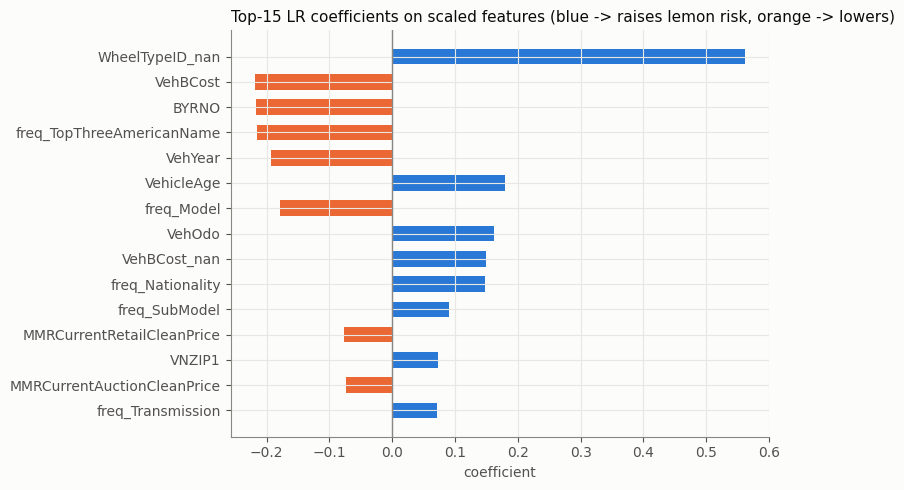

strongest signals:
WheelTypeID_nan              0.561
VehBCost                    -0.218
BYRNO                       -0.217
freq_TopThreeAmericanName   -0.216
VehYear                     -0.193
VehicleAge                   0.180
freq_Model                  -0.180
VehOdo                       0.163


In [18]:
lr_full = LogisticRegression(max_iter=2000, random_state=RANDOM_STATE).fit(Xtr_fe, y_train)
coefs = pd.Series(lr_full.coef_[0], index=fe_feature_names)
top = coefs.reindex(coefs.abs().sort_values(ascending=False).index)[:15][::-1]

fig, ax = plt.subplots(figsize=(8, 5))
colors = [C_BLUE if v > 0 else C_ORANGE for v in top.values]
ax.barh(top.index, top.values, color=colors, height=0.62)
ax.axvline(0, color=MUTED, lw=1)
ax.set_title("Top-15 LR coefficients on scaled features "
             "(blue -> raises lemon risk, orange -> lowers)", loc="left", fontsize=11)
ax.set_xlabel("coefficient")
plt.tight_layout()
plt.show()

print("strongest signals:")
print(coefs.reindex(coefs.abs().sort_values(ascending=False).index)[:8].round(3).to_string())

In [19]:
order = coefs.abs().sort_values(ascending=False).index
rows = []
for k in [5, 10, 15, 20, 30, 40, len(fe_feature_names)]:
    keep = [fe_feature_names.index(f) for f in order[:k]]
    lr = LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)
    lr.fit(Xtr_fe[:, keep], y_train)
    g = my_gini(y_valid, lr.predict_proba(Xva_fe[:, keep])[:, 1])
    rows.append({"approach": f"manual top-{k}", "n_features": k, "validation Gini": g})

for C in [0.003, 0.01, 0.03, 0.1, 1.0]:
    lr = LogisticRegression(l1_ratio=1, solver="liblinear", C=C, max_iter=2000,
                            random_state=RANDOM_STATE)
    lr.fit(Xtr_fe, y_train)
    g = my_gini(y_valid, lr.predict_proba(Xva_fe)[:, 1])
    rows.append({"approach": f"L1, C={C}", "n_features": int((lr.coef_ != 0).sum()),
                 "validation Gini": g})

selection_table = pd.DataFrame(rows).set_index("approach")
selection_table.round(4)

,n_features,validation Gini
approach,,
manual top-5,5,0.4676
manual top-10,10,0.4841
manual top-15,15,0.4775
manual top-20,20,0.4810
manual top-30,30,0.4776
manual top-40,40,0.4801
manual top-51,51,0.4800
"L1, C=0.003",5,0.4760
"L1, C=0.01",13,0.4834


**Which approach is better?** Both beat the full model — dropping noisy features helps —
and their best scores are nearly identical (manual top-10 ~0.484 vs L1 with `C=0.01`
~0.483, difference well within noise). In terms of raw validation Gini the **manual
top-k elimination is marginally better here**, but **L1 is the more practical approach**:
it selects the sparsity level in a single fit per `C`, handles correlated groups
consistently, and does not require a human to choose k by trial. The strongest features
agree between both methods: `freq_WheelType` / `WheelTypeID` and their missingness flag
(an unknown wheel type is a big red flag), the vehicle age/year, the odometer, the
`ratio_cost_mmr` engineered price ratio and the auction frequency.

## Step 9. Best model + hyperparameter tuning on validation

The best algorithm is **Logistic Regression** and the best feature set is the Step 7 one
(base + engineered features). We grid-search its main hyperparameters on the validation
set: the inverse regularisation strength `C` and `class_weight` (the classes are 1:7
imbalanced). For completeness we also revisit KNN's `n_neighbors`/`weights` to confirm
it cannot catch up.

In [20]:
rows = []
for C in [0.003, 0.01, 0.03, 0.1, 0.3, 1.0]:
    for cw in [None, "balanced"]:
        lr = LogisticRegression(C=C, class_weight=cw, max_iter=2000,
                                random_state=RANDOM_STATE).fit(Xtr_fe, y_train)
        g = my_gini(y_valid, lr.predict_proba(Xva_fe)[:, 1])
        rows.append({"C": C, "class_weight": str(cw), "validation Gini": g})
grid_lr = pd.DataFrame(rows).sort_values("validation Gini", ascending=False)
grid_lr.round(4).head(6)

,C,class_weight,validation Gini
1,0.003,balanced,0.4859
3,0.010,balanced,0.4846
5,0.030,balanced,0.4833
7,0.100,balanced,0.4822
0,0.003,None,0.4821
2,0.010,None,0.4817


In [21]:
rows = []
for k in [11, 31, 51, 101, 201]:
    for w in ["uniform", "distance"]:
        knn = KNeighborsClassifier(n_neighbors=k, weights=w, n_jobs=-1)
        knn.fit(Xtr_fe, y_train)
        g = my_gini(y_valid, knn.predict_proba(Xva_fe)[:, 1])
        rows.append({"n_neighbors": k, "weights": w, "validation Gini": g})
grid_knn = pd.DataFrame(rows).sort_values("validation Gini", ascending=False)
print("KNN tuning (still far below LR):")
grid_knn.round(4).head(4)

KNN tuning (still far below LR):


,n_neighbors,weights,validation Gini
9,201,distance,0.4688
8,201,uniform,0.4636
7,101,distance,0.4605
6,101,uniform,0.4562


In [22]:
best_row = grid_lr.iloc[0]
best_cw = None if best_row["class_weight"] == "None" else best_row["class_weight"]
best_model = LogisticRegression(C=best_row["C"], class_weight=best_cw, max_iter=2000,
                                random_state=RANDOM_STATE).fit(Xtr_fe, y_train)
print(f"BEST MODEL: LogisticRegression(C={best_row['C']}, class_weight={best_cw}) "
      f"on base + engineered features")
print(f"validation Gini = {best_row['validation Gini']:.4f} "
      f"(untuned: {fe_valid_gini['LogisticRegression']:.4f})")

BEST MODEL: LogisticRegression(C=0.003, class_weight=balanced) on base + engineered features
validation Gini = 0.4859 (untuned: 0.4800)


**Which hyperparameters have the most impact?**

* **`C` (regularisation strength) matters most**: pushing it down to ~0.01 (i.e. strong
  L2 shrinkage) gives the largest single gain — with ~50 partially noisy, correlated
  features and temporal drift, shrinking weights generalises better forward in time.
* **`class_weight='balanced'` adds a small consistent bump** at every `C`. It mostly
  matters for hard-label thresholding, but here it also slightly improves ranking.
* For KNN, `n_neighbors` is the dominant knob (small k is far too noisy; k=201 with
  distance weights is its best), `weights` is secondary — the best KNN narrows the gap to
  ~0.017 Gini but still does not catch the tuned LR on validation.

## Step 10. Final check: train / valid / test Gini of the best model

Only now, with the model fully frozen, do we touch the **test set** for the first time.

In [23]:
final_scores = pd.Series({
    "train": my_gini(y_train, best_model.predict_proba(Xtr_fe)[:, 1]),
    "valid": my_gini(y_valid, best_model.predict_proba(Xva_fe)[:, 1]),
    "test": my_gini(y_test, best_model.predict_proba(Xte_fe)[:, 1]),
}, name="Gini").to_frame()
final_scores.round(4)

,Gini
train,0.5126
valid,0.4859
test,0.3726


**Is there a drop? Is the model overfitted?**

* **train -> valid** shows only a small gap (~0.513 -> ~0.486). The heavily regularised
  linear model clearly does **not** memorise the training data — by the classic
  definition (large train-vs-holdout gap) it is *not overfitted*.
* **valid -> test** shows a much larger drop (~0.486 -> ~0.373). This is *not* classical
  overfitting either — the test rows come from a **later time period** (May–Dec 2010 vs
  Sep 2009–Apr 2010 for validation), so the drop is dominated by **temporal distribution
  shift**: market prices, auction mix and the lemon base rate all drift, and the
  frequency/group-mean encodings and price-level coefficients slowly go stale. A
  secondary contribution is **selection overfitting to the validation set**: we queried
  validation many times (feature selection, elimination, tuning), so its score is an
  optimistic estimate of forward performance. The honest generalisation estimate is the
  test Gini ~0.37 — a clear degradation, but still far better than chance, and a good
  illustration of why time-based evaluation matters: a random split would have hidden
  this entire effect.

## Step 11. Recall, Precision, F1 and AUC PR from scratch; test-set comparison

Hard-label metrics at threshold 0.5 (with $TP$, $FP$, $FN$ from the confusion matrix):

$$\mathrm{Recall} = \frac{TP}{TP + FN}, \qquad
\mathrm{Precision} = \frac{TP}{TP + FP}, \qquad
F_1 = \frac{2 \cdot P \cdot R}{P + R}.$$

**AUC PR** (average precision) summarises the precision–recall curve. We build the curve
from scratch: sort by score descending, take each **distinct score** as a threshold,
compute cumulative $TP_k$/$FP_k$, and sum the step-wise area
$\mathrm{AP} = \sum_k (R_k - R_{k-1})\,P_k$ — the same step-interpolation sklearn's
`average_precision_score` uses, so the values must match exactly.

In [24]:
def my_recall(y_true, y_pred):
    y_true, y_pred = np.asarray(y_true), np.asarray(y_pred)
    tp = ((y_pred == 1) & (y_true == 1)).sum()
    fn = ((y_pred == 0) & (y_true == 1)).sum()
    return tp / (tp + fn) if tp + fn else 0.0


def my_precision(y_true, y_pred):
    y_true, y_pred = np.asarray(y_true), np.asarray(y_pred)
    tp = ((y_pred == 1) & (y_true == 1)).sum()
    fp = ((y_pred == 1) & (y_true == 0)).sum()
    return tp / (tp + fp) if tp + fp else 0.0


def my_f1(y_true, y_pred):
    p, r = my_precision(y_true, y_pred), my_recall(y_true, y_pred)
    return 2 * p * r / (p + r) if p + r else 0.0


def my_pr_curve(y_true, y_score):
    """Precision-recall points at every distinct score threshold (descending)."""
    y_true = np.asarray(y_true)
    y_score = np.asarray(y_score)
    order = np.argsort(-y_score, kind="mergesort")
    y_sorted, s_sorted = y_true[order], y_score[order]
    distinct = np.r_[np.nonzero(np.diff(s_sorted))[0], len(s_sorted) - 1]
    tps = np.cumsum(y_sorted)[distinct]
    fps = 1 + distinct - tps
    precision = tps / (tps + fps)
    recall = tps / y_true.sum()
    return precision, recall


def my_average_precision(y_true, y_score):
    precision, recall = my_pr_curve(y_true, y_score)
    return float(np.sum(np.diff(np.r_[0.0, recall]) * precision))


# verify against sklearn on the best model's validation predictions
proba_va = best_model.predict_proba(Xva_fe)[:, 1]
pred_va = (proba_va > 0.5).astype(int)
checks = [
    ("Recall", my_recall(y_valid, pred_va), recall_score(y_valid, pred_va)),
    ("Precision", my_precision(y_valid, pred_va), precision_score(y_valid, pred_va)),
    ("F1", my_f1(y_valid, pred_va), f1_score(y_valid, pred_va)),
    ("AUC PR", my_average_precision(y_valid, proba_va),
     average_precision_score(y_valid, proba_va)),
]
for name, mine, sk in checks:
    assert abs(mine - sk) < 1e-6, (name, mine, sk)
    print(f"{name:10s} mine = {mine:.6f} | sklearn = {sk:.6f} -> match")

Recall     mine = 0.551670 | sklearn = 0.551670 -> match
Precision  mine = 0.286339 | sklearn = 0.286339 -> match
F1         mine = 0.377000 | sklearn = 0.377000 -> match
AUC PR     mine = 0.387032 | sklearn = 0.387032 -> match


In [25]:
# compare ALL algorithms on the TEST set with AUC PR (models trained on the FE feature
# set); the validation AUC PR is shown alongside for reference
test_models = {
    "LogisticRegression (tuned)": best_model,
    "LogisticRegression": sk_models_fe["LogisticRegression"],
    "GaussianNB": sk_models_fe["GaussianNB"],
    "KNN (k=51)": sk_models_fe["KNN (k=51)"],
    "MyLogisticRegression": MyLogisticRegression().fit(Xtr_fe, y_train),
    "MyGaussianNB": MyGaussianNB().fit(Xtr_fe, y_train),
    "MyKNN (k=51)": MyKNN(n_neighbors=51).fit(Xtr_fe, y_train),
}

rows, test_proba = [], {}
for name, model in test_models.items():
    proba = model.predict_proba(Xte_fe)[:, 1]
    test_proba[name] = proba
    rows.append({"model": name,
                 "valid AUC PR": my_average_precision(
                     y_valid, model.predict_proba(Xva_fe)[:, 1]),
                 "test AUC PR": my_average_precision(y_test, proba),
                 "test Gini": my_gini(y_test, proba)})

aucpr_table = (pd.DataFrame(rows).set_index("model")
               .sort_values("test AUC PR", ascending=False))
print(f"baseline AUC PR (random classifier) = test lemon rate = {y_test.mean():.4f}\n")
aucpr_table.round(4)

baseline AUC PR (random classifier) = test lemon rate = 0.1226



,valid AUC PR,test AUC PR,test Gini
model,,,
KNN (k=51),0.3916,0.4238,0.4437
MyKNN (k=51),0.3916,0.4238,0.4437
LogisticRegression (tuned),0.3870,0.2242,0.3726
GaussianNB,0.3662,0.1930,0.3393
MyGaussianNB,0.3662,0.1929,0.3392
LogisticRegression,0.3907,0.1727,0.3224
MyLogisticRegression,0.3909,0.1720,0.3228


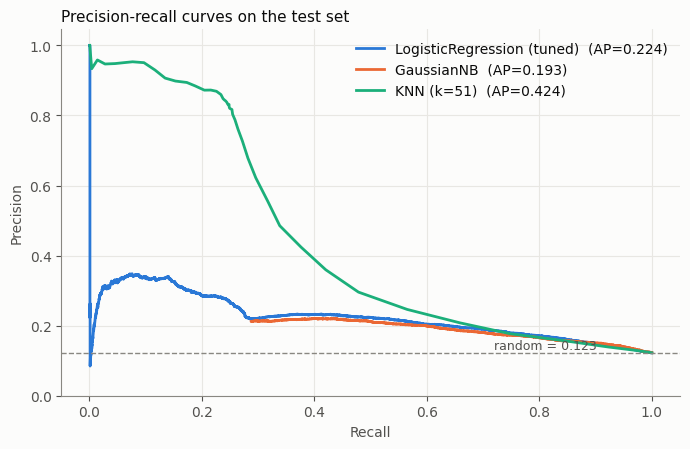

In [26]:
fig, ax = plt.subplots(figsize=(7, 4.6))
curves = [("LogisticRegression (tuned)", C_BLUE),
          ("GaussianNB", C_ORANGE),
          ("KNN (k=51)", C_AQUA)]
for name, color in curves:
    precision, recall = my_pr_curve(y_test, test_proba[name])
    ap = my_average_precision(y_test, test_proba[name])
    ax.plot(recall, precision, color=color, lw=2, label=f"{name}  (AP={ap:.3f})")
ax.axhline(y_test.mean(), color=MUTED, lw=1, ls="--")
ax.annotate(f"random = {y_test.mean():.3f}", xy=(0.72, y_test.mean() + 0.012),
            color=INK2, fontsize=9)
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Precision-recall curves on the test set", loc="left", fontsize=11)
ax.legend(frameon=False)
ax.set_ylim(0, None)
plt.tight_layout()
plt.show()

**Test-set comparison (AUC PR) — an instructive surprise.** The custom implementations
track their sklearn counterparts almost exactly (KNN and MyKNN agree to 4 decimals, same
for the two Naive Bayes and the two logistic regressions), which again confirms the
from-scratch models are correct. But the *ranking of algorithms flips* relative to the
validation Gini leaderboard:

* **KNN is the clear winner on the test set** (AUC PR ~0.42), even though it lost on
  validation Gini. Two effects combine here. First, the metric: as the "valid AUC PR"
  column shows, KNN already narrowly led on validation *AUC PR* (~0.392 vs ~0.391 for
  untuned LR and ~0.387 for the tuned one) — its neighbourhood-vote probabilities
  concentrate lemons at the very top of the ranking, which AUC PR rewards and the
  rank-global Gini does not. Second, and mainly, robustness: KNN's local similarity
  structure ("cars like this one were lemons") survives the 2010 distribution shift far
  better than LR's global coefficients on drifting price levels — its AUC PR even
  *rises* from validation to test while every other model falls.
* **Logistic Regression degrades most** valid -> test (as analysed in Step 10): its
  strongest features (frequency encodings, price coefficients) go stale in the later
  period; tuning still helps it (tuned 0.224 vs untuned 0.173 AUC PR).
* All models sit well above the random baseline (AUC PR = positive rate ~0.12).

Takeaway: model selection done on one metric and one time slice does not automatically
transfer — with 1:7 imbalance and temporal drift, the PR view on truly held-out future
data is the honest picture, and a production candidate should be stress-tested exactly
this way before deployment.

## Step 12. Which hard-label metric is preferred for detecting lemon cars?

**A recall-leaning metric — recall itself, operationally wrapped as an
F-beta score with beta > 1 (e.g. F2).**

Reasoning from the costs of the two error types:

* **A missed lemon (false negative) is expensive.** The dealer actually buys the car and
  eats the full loss: the purchase price of an unsellable vehicle, transportation, repair
  attempts, floor space — hundreds to thousands of dollars per miss.
* **A false alarm (false positive) is cheap.** Flagging a good car merely triggers a more
  careful inspection or skipping one of many similar auction cars — a small opportunity
  or inspection cost.

With such asymmetric costs we should be willing to trade several false positives for one
avoided false negative, so plain **accuracy is useless** (predicting "never a lemon" is
88 % accurate and catches nothing) and the symmetric **F1 undervalues recall**.

* **Recall** directly measures "what share of lemons we catch", which is the business
  goal — but optimising recall *alone* is degenerate (flag everything -> recall = 1).
* **F-beta with beta > 1** (say **F2**, weighting recall four times as much as precision)
  keeps the recall focus while still penalising an all-positive classifier — this is the
  metric we would put in a monitoring dashboard.
* The decision **threshold should then be tuned for F2** (typically well below 0.5 for a
  1:7 imbalanced problem), ideally on top of a probability model selected by AUC PR /
  Gini, and `class_weight='balanced'` from Step 9 pushes in the same direction.

**Summary: prefer recall, controlled via F-beta (beta > 1, e.g. F2), because a missed
lemon costs far more than an unnecessary inspection.**